# So sánh & lựa chọn mô hình: KNN vs Naive Bayes

Notebook này huấn luyện **2 thuật toán** trên cùng một bộ dữ liệu rồi so sánh để **chọn mô hình** cho chatbot.

> Chạy `02_tien_xu_ly/tien_xu_ly_data.ipynb` trước để có `features.csv`.

**Ta đo 3 con số dễ hiểu:**
- **Top-1 (accuracy):** đoán đúng ngay bệnh ở vị trí số 1.
- **Top-3 / Top-5:** bệnh đúng có nằm trong 3 / 5 bệnh "nghi ngờ nhất" không.

Vì có **400 bệnh**, đoán mò chỉ đúng $1/400 = 0{,}25\%$ → với chatbot, gợi ý đúng trong **Top-5** đã là rất hữu ích.

## Bước 1. Đọc dữ liệu & chia train/test

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, top_k_accuracy_score

data = pd.read_csv("../01_data/processed/features.csv")
X = data.drop(columns=["Benh"])                 # 135 cot trieu chung
le = LabelEncoder()
y = le.fit_transform(data["Benh"])              # nhan benh -> so
benh_ids = np.arange(len(le.classes_))

# 80% hoc, 20% kiem tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape, "| So benh:", len(le.classes_))

Train: (4000, 135) | Test: (1000, 135) | So benh: 400


## Bước 2. Huấn luyện 2 mô hình & đo điểm

Hàm `danh_gia` làm đúng 3 việc: **học** → **đoán** → **tính điểm** Top-1/3/5.

In [2]:
def danh_gia(ten, model):
    model.fit(X_train, y_train)                 # 1) HOC tu tap train
    proba = model.predict_proba(X_test)         # 2) xac suat 400 benh cho moi ca test
    y_pred = model.predict(X_test)              #    benh duoc chon (xac suat cao nhat)
    return {                                    # 3) TINH DIEM
        "Mo hinh": ten,
        "Top-1 (accuracy)": round(accuracy_score(y_test, y_pred), 3),
        "Top-3": round(top_k_accuracy_score(y_test, proba, k=3, labels=benh_ids), 3),
        "Top-5": round(top_k_accuracy_score(y_test, proba, k=5, labels=benh_ids), 3),
    }

ket_qua = [
    danh_gia("KNN (k=5)",   KNeighborsClassifier(n_neighbors=5)),
    danh_gia("Naive Bayes", GaussianNB()),
]
bang = pd.DataFrame(ket_qua).set_index("Mo hinh")
bang

,Top-1 (accuracy),Top-3,Top-5
Mo hinh,,,
KNN (k=5),0.278,0.496,0.58
Naive Bayes,0.316,0.564,0.70


## Bước 3. Vẽ biểu đồ so sánh

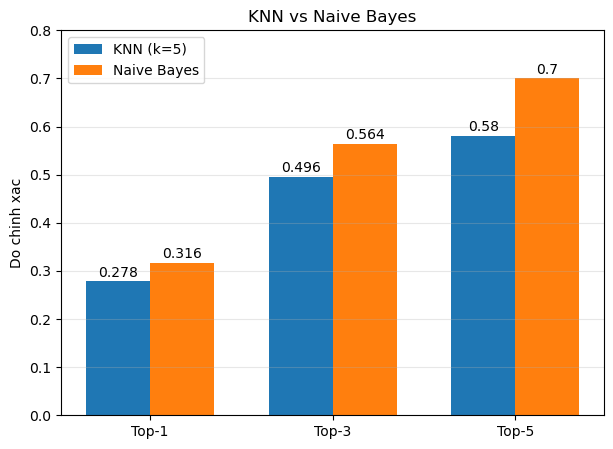

In [3]:
import matplotlib.pyplot as plt

cot = ["Top-1 (accuracy)", "Top-3", "Top-5"]
nhan = ["Top-1", "Top-3", "Top-5"]
x = np.arange(3); w = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - w/2, bang.loc["KNN (k=5)", cot],   w, label="KNN (k=5)")
plt.bar(x + w/2, bang.loc["Naive Bayes", cot], w, label="Naive Bayes")
for i, c in enumerate(cot):
    plt.text(i - w/2, bang.loc["KNN (k=5)", c]+.01,   bang.loc["KNN (k=5)", c],   ha="center")
    plt.text(i + w/2, bang.loc["Naive Bayes", c]+.01, bang.loc["Naive Bayes", c], ha="center")
plt.xticks(x, nhan); plt.ylim(0, .8); plt.ylabel("Do chinh xac")
plt.title("KNN vs Naive Bayes")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.show()

## Bước 4. Kết luận

| | KNN | Naive Bayes |
|---|---|---|
| Cách làm | Tìm các ca bệnh **giống nhất** rồi bỏ phiếu | Tính **xác suất** từng bệnh (định lý Bayes) |
| Huấn luyện | Rất nhanh (chỉ lưu dữ liệu) | Rất nhanh |
| Khi đoán | **Chậm** (phải so với toàn bộ dữ liệu) | Nhanh |
| Điểm số | Thấp hơn ở cả Top-1/3/5 | **Cao hơn ở cả Top-1/3/5** |

### ✅ Chọn **Naive Bayes**

- **Top-5 ≈ 0,70**: bot gợi ý 5 bệnh thì bệnh đúng có mặt ~7/10 lần → đủ tốt để **sàng lọc, tham khảo**.
- Xuất **xác suất từng bệnh** → hiển thị tự nhiên kiểu "khả năng mắc bệnh X: __%".
- Huấn luyện & đoán **nhanh**.

> Điểm số tuyệt đối còn thấp vì **400 bệnh nhưng dữ liệu thưa** (mỗi ca chỉ 4–8 triệu chứng). Cải thiện: thêm dữ liệu, gộp bệnh theo chuyên khoa.